A little test to make sure the addition of wind speed didn't break anything, and to see conceptually how it compares to viewing error in each component separately.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
metric = "rmse"
error = {
    name: xr.open_dataset(
        f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/baselines/{key}-forecasts-vs-hrrr-analysis/trim10/obs-metrics/{metric}.convobs.lam.nc",
        decode_timedelta=True,
    )
    for name, key in zip(["HRRR", "GFS"], ["hrrr", "gfs"])
}
#error["Nested-EAGLE 1\u00B0/15km"] = xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse24h/experiments/lr/lr1.00e-4/inference-validation/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)
error["Nested-EAGLE 1\u00B0/15km"] = xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse06h/experiments/latent-updates/heal5/inference-validation/obs-metrics-test/{metric}.convobs.nested-lam.nc", decode_timedelta=True)

In [4]:
original = xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse06h/experiments/latent-updates/heal5/inference-validation/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)

In [6]:
for key in original.data_vars:
    diff = error["Nested-EAGLE 1\u00B0/15km"][key] - original[key]
    err = np.abs(diff)
    print(f"{key} {err.max().values}")

geopotential_height 0.0
zonal_wind 0.0
meridional_wind 0.0
temperature 0.0
specific_humidity 0.0
surface_pressure 0.0
10m_zonal_wind 1.7763568394002505e-15
10m_meridional_wind 8.881784197001252e-16
2m_temperature 1.7763568394002505e-15
2m_specific_humidity 0.0


In [29]:
error = {k: error[k] for k in ["Nested-EAGLE 1\u00B0/15km", "HRRR", "GFS"]}

In [30]:
nice_names = lambda name : name.replace("_", " ").capitalize()

In [31]:
def single_plot(ax, dsdict, varname, sel=None, **kwargs):
    estimator = kwargs.pop("estimator", "median")
    for label, xds in error.items():
        if "Nested" in label:
            color = "C0"
        elif "HRRR" in label:
            color = "C1"
        elif "GFS" in label:
            color = "C2"

        plotme = xds[varname] if sel is None else xds[varname].sel(**sel)
        df = plotme.to_dataframe().reset_index()
        sns.lineplot(
            data=df,
            x="fhr",
            y=varname,
            ax=ax,
            label=label,
            color=color,
            estimator=estimator,
            **kwargs,
        )
    xticks = plotme.fhr.values
    xticks = xticks if len(xticks)<10 else np.concatenate([ [xticks[0]], xticks[4::4]])
    ax.set(
        ylabel=metric.upper() if ax.get_subplotspec().is_first_col() else "",
        xlabel="Forecast Hour" if ax.get_subplotspec().is_last_row() else "",
        title=nice_names(varname) if ax.get_subplotspec().is_first_row() else "",
        xticks=xticks,
    )
    ax.legend(frameon=False)

In [32]:
def plot_surface_error(surface_vars, **kwargs):
    ncols = len(surface_vars)
    fig, axs = plt.subplots(1, ncols, figsize=(5*ncols, 4), constrained_layout=True)
    
    for varname, ax in zip(surface_vars, axs):
        single_plot(ax=ax, dsdict=error, varname=varname, **kwargs)
    return fig, axs

In [33]:
def plot_level_vars(level_vars, **kwargs):
    
    levels = error["HRRR"].level.values
    ncols = len(level_vars)
    nrows = len(levels)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), constrained_layout=True)

    if ncols == 1:
        axs = [axs]
    if nrows == 1:
        axs = [axs]
    

    sel = kwargs.pop("sel", {})
    for level, axr in zip(levels, axs):
        for varname, ax in zip(level_vars, axr):
            
            sel["level"] = level
            single_plot(ax=ax, dsdict=error, varname=varname, sel=sel, **kwargs)
            ax.legend(title=f"{level} hPa", frameon=False)
    return fig, axs

In [34]:
surface_fields = ["surface_pressure", "10m_wind_speed", "10m_zonal_wind", "10m_meridional_wind", "2m_temperature", "2m_specific_humidity"]

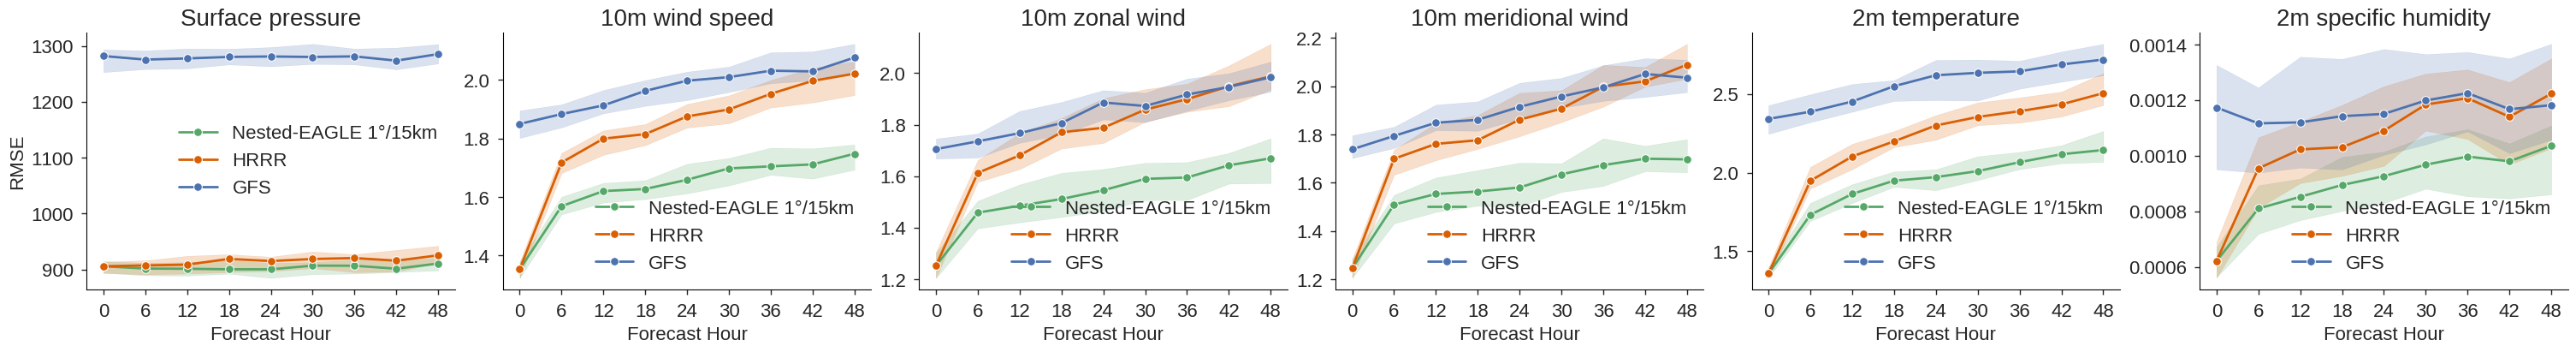

In [35]:
fig, axs = plot_surface_error(surface_fields, sel={"fhr": slice(49)}, marker="o")
#fig.savefig(f"figures/surface_48h_rmse_5fields.jpeg", dpi=300, bbox_inches="tight")

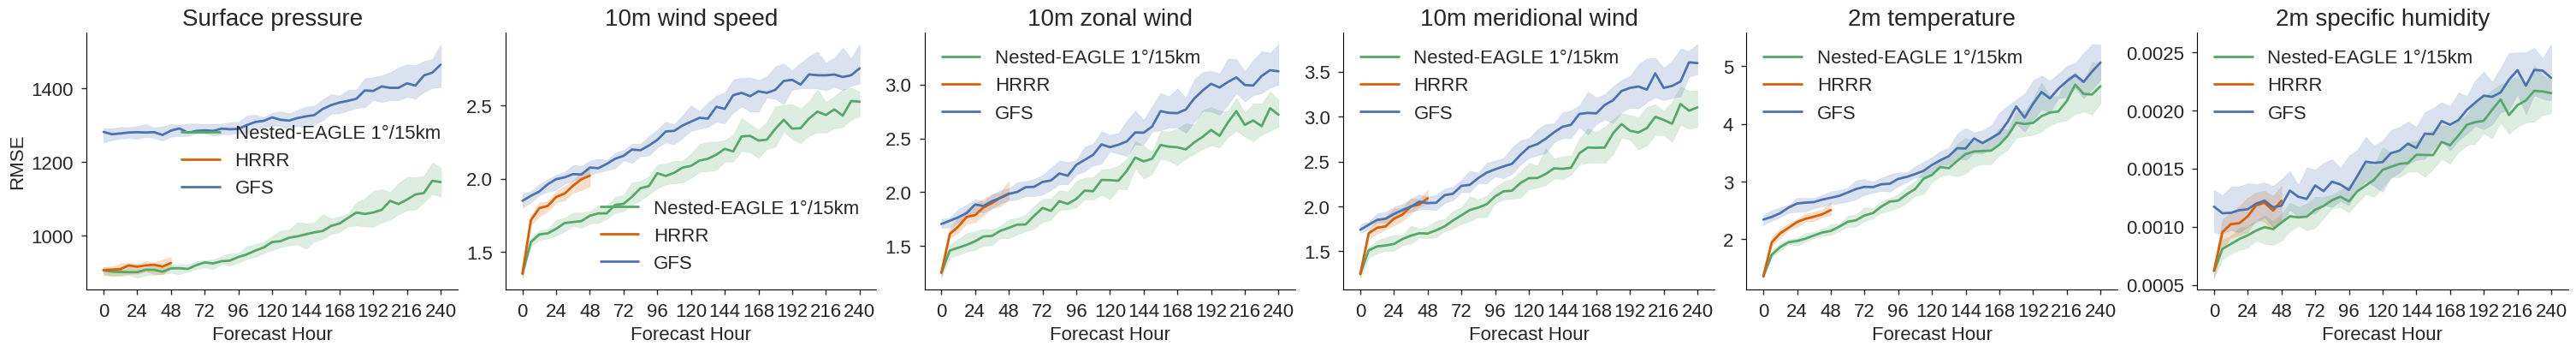

In [36]:
fig, axs = plot_surface_error(surface_fields)
#fig.savefig(f"figures/surface_10d_rmse_5fields.jpeg", dpi=300, bbox_inches="tight")

In [37]:
pressure_fields = ["geopotential_height", "wind_speed", "zonal_wind", "meridional_wind", "temperature", "specific_humidity"]

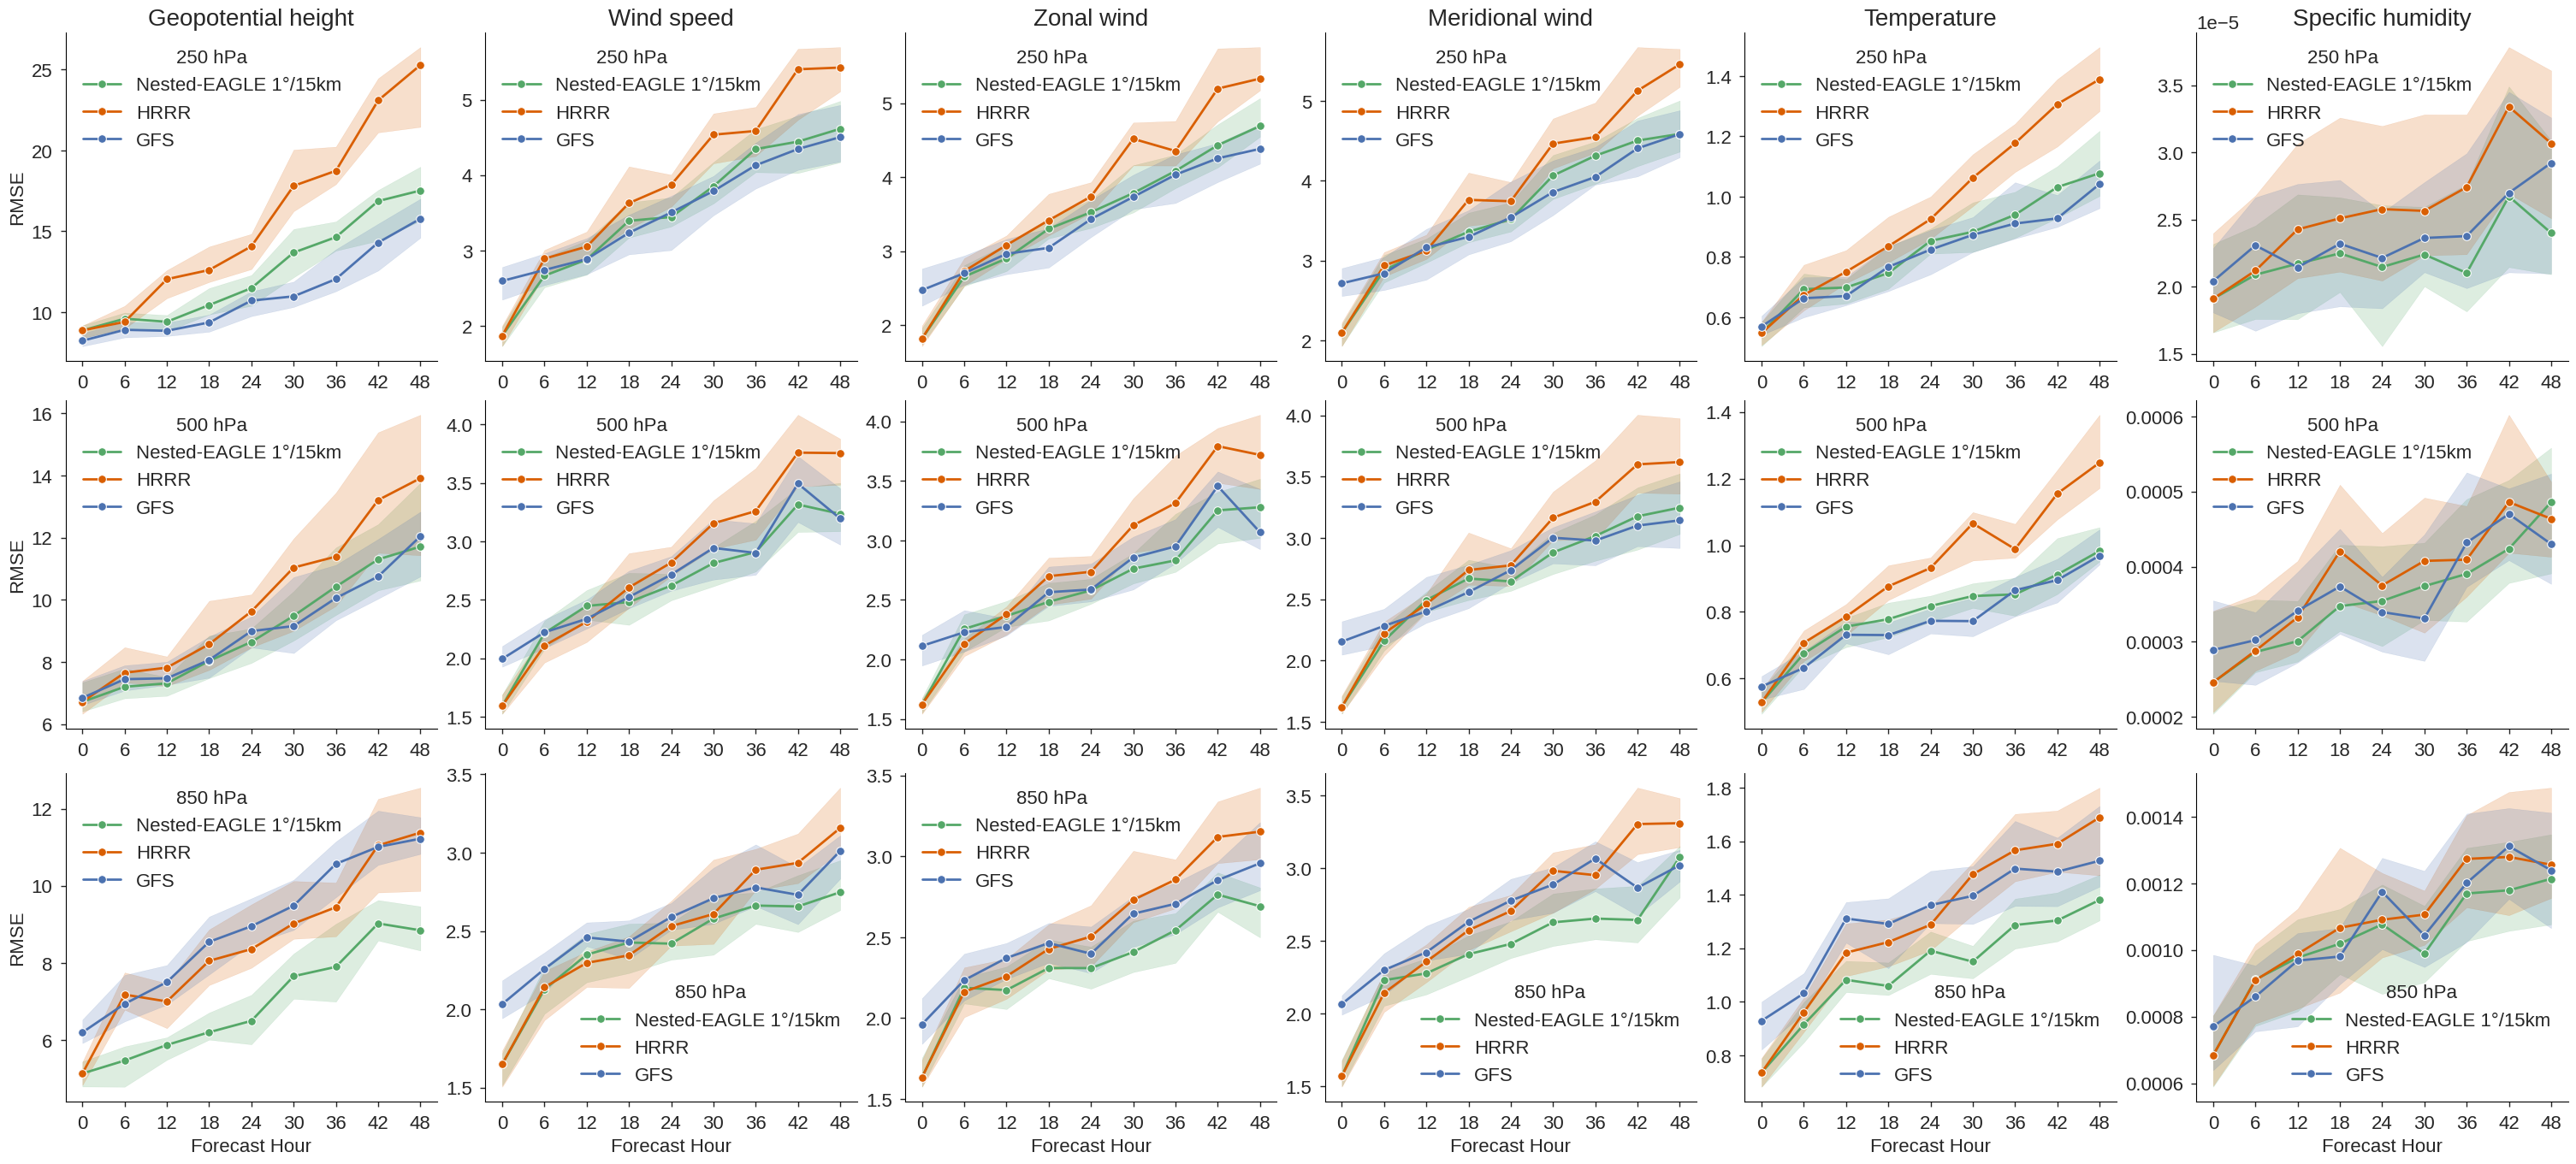

In [38]:
fig, axs = plot_level_vars(pressure_fields, sel={"fhr": slice(49)}, marker="o")
#fig.savefig(f"figures/plevel_48h_rmse_6fields.jpeg", dpi=300, bbox_inches="tight")

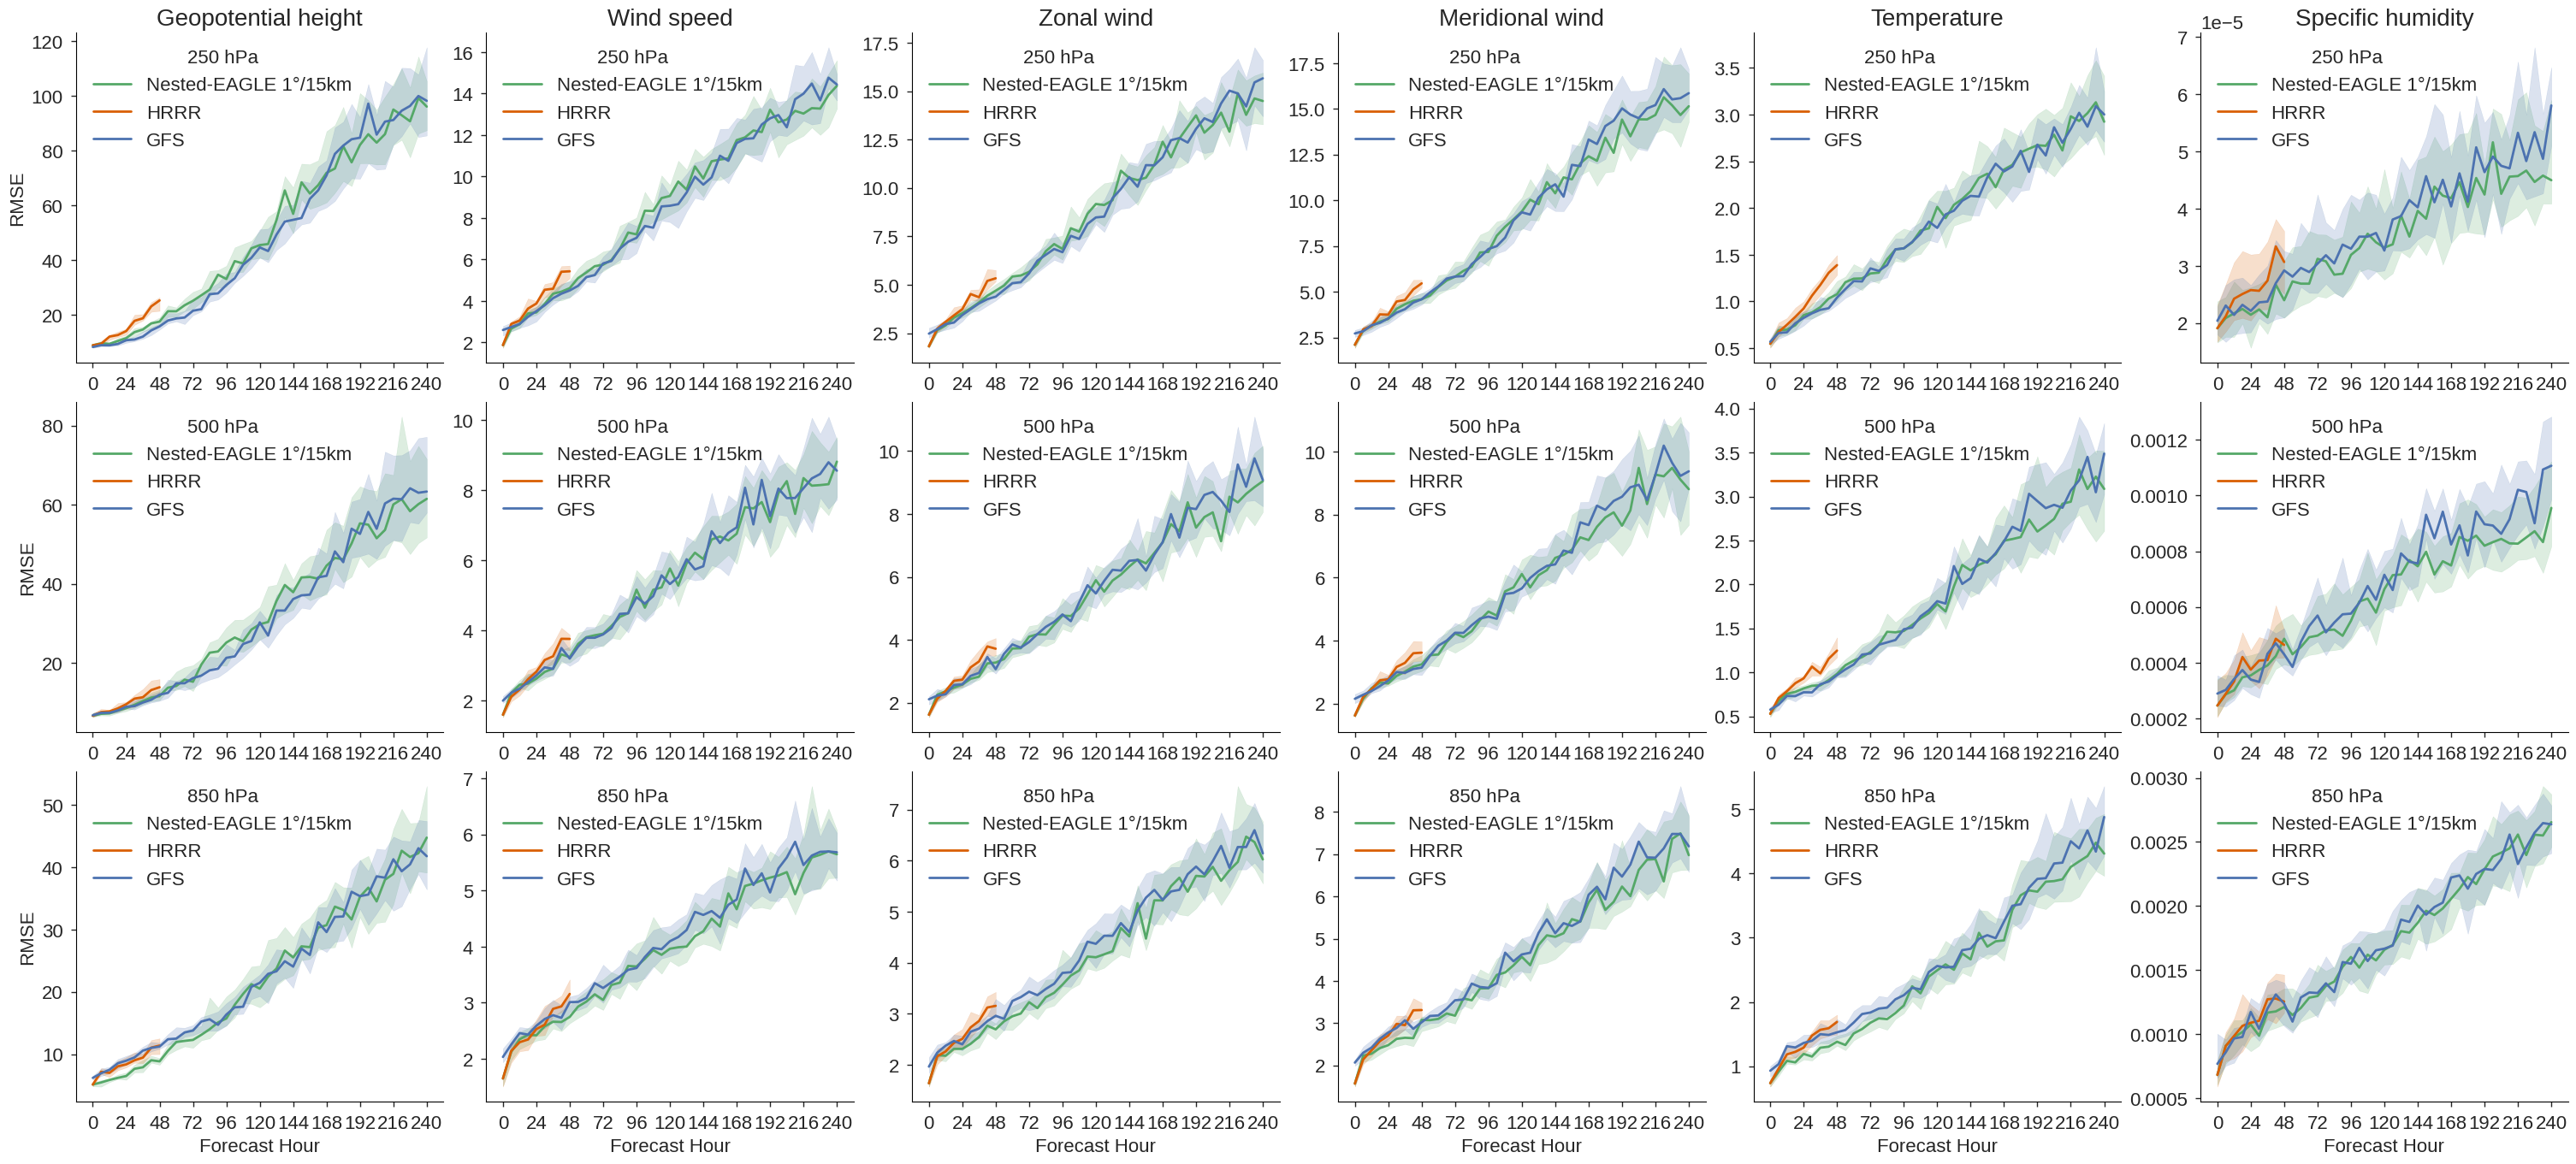

In [39]:
fig, axs = plot_level_vars(pressure_fields)
#fig.savefig(f"figures/plevel_10d_rmse_6fields.jpeg", dpi=300, bbox_inches="tight")